In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
data_train_path = r'C:\Users\HP\Contacts\OneDrive\Desktop\jupyter\data\train'
data_test_path = r'C:\Users\HP\Contacts\OneDrive\Desktop\jupyter\data\test'
data_val_path = r'C:\Users\HP\Contacts\OneDrive\Desktop\jupyter\data\val'

In [3]:
img_width = 180
img_height =180 

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 14215 files belonging to 61 classes.


In [5]:
data_categories = data_train.class_names
data_categories

['Aloevera',
 'Amla',
 'Amruta_Balli',
 'Arali',
 'Arive-Dantu',
 'Ashoka',
 'Ashwagandha',
 'Avacado',
 'Bamboo',
 'Basale',
 'Betel',
 'Betel_Nut',
 'Brahmi',
 'Castor',
 'Crape_Jasmine',
 'Curry',
 'Curry_Leaf',
 'Doddapatre',
 'Drumstick',
 'Ekka',
 'Fenugreek',
 'Ganike',
 'Gauva',
 'Geranium',
 'Guava',
 'Henna',
 'Hibiscus',
 'Honge',
 'Indian_Beech',
 'Indian_Mustard',
 'Insulin',
 'Jackfruit',
 'Jamaica_Cherry-Gasagase',
 'Jamun',
 'Jasmine',
 'Karanda',
 'Lemon',
 'Lemon_grass',
 'Mango',
 'Mexican_Mint',
 'Mint',
 'Nagadali',
 'Neem',
 'Nithyapushpa',
 'Nooni',
 'Oleander',
 'Pappaya',
 'Parijata',
 'Peepal',
 'Pepper',
 'Pomegranate',
 'Raktachandini',
 'Rasna',
 'Rose',
 'Rose_apple',
 'Roxburgh_fig',
 'Sandalwood',
 'Sapota',
 'Tulasi',
 'Tulsi',
 'Wood_sorel']

In [6]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                       shuffle=False,
                                                       validation_split=False)

Found 4056 files belonging to 61 classes.


In [7]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 2054 files belonging to 61 classes.


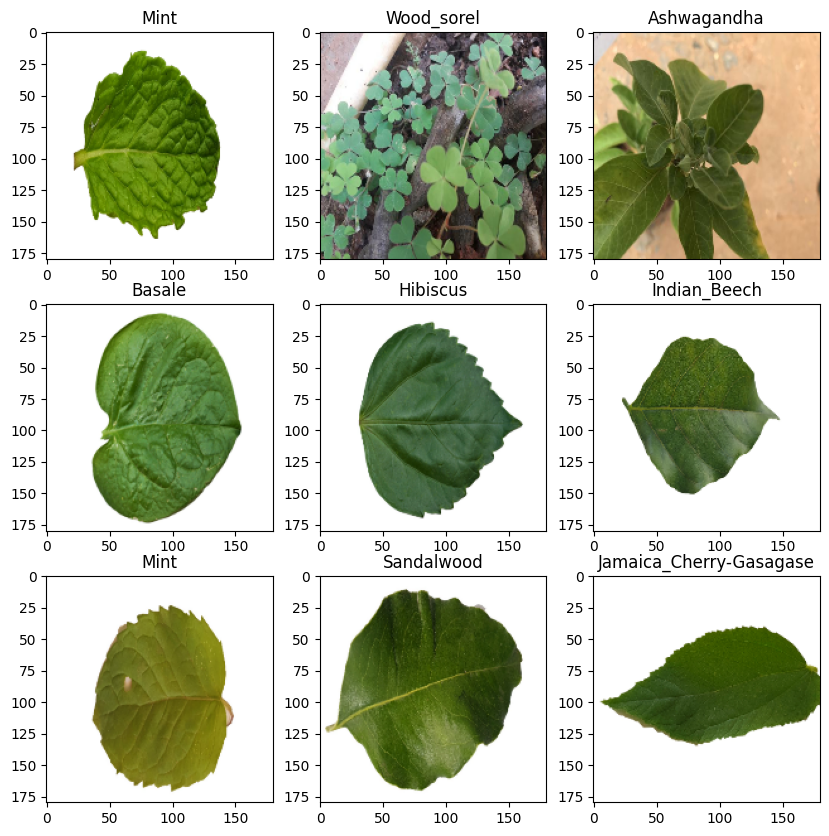

In [8]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_categories[labels[i]])

In [9]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [10]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), 
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),  
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),  
    layers.MaxPooling2D(),  
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_categories))
])

In [11]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [12]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 125s 275ms/step - accuracy: 0.2733 - loss: 2.7659 - val_accuracy: 0.5994 - val_loss: 1.4030
Epoch 2/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.6636 - loss: 1.1796 - val_accuracy: 0.7256 - val_loss: 0.9525
Epoch 3/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.7857 - loss: 0.7271 - val_accuracy: 0.8129 - val_loss: 0.6527
Epoch 4/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.8521 - loss: 0.4935 - val_accuracy: 0.8311 - val_loss: 0.6160
Epoch 5/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 243ms/step - accuracy: 0.8849 - loss: 0.3834 - val_accuracy: 0.8501 - val_loss: 0.5488
Epoch 6/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 244ms/step - accuracy: 0.9127 - loss: 0.2803 - val_accuracy: 0.8380 - val_loss: 0.5728
Epoch 7/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.9315 - loss: 0.2148 - val_accuracy: 0.8538 - val_loss: 0.6000
Epoch 8/25
445/445 ━━━━━━━━━━━━━━━━━━━━ 108s 243ms/step - accuracy: 0.9408 -

Text(0.5, 1.0, 'Loss')

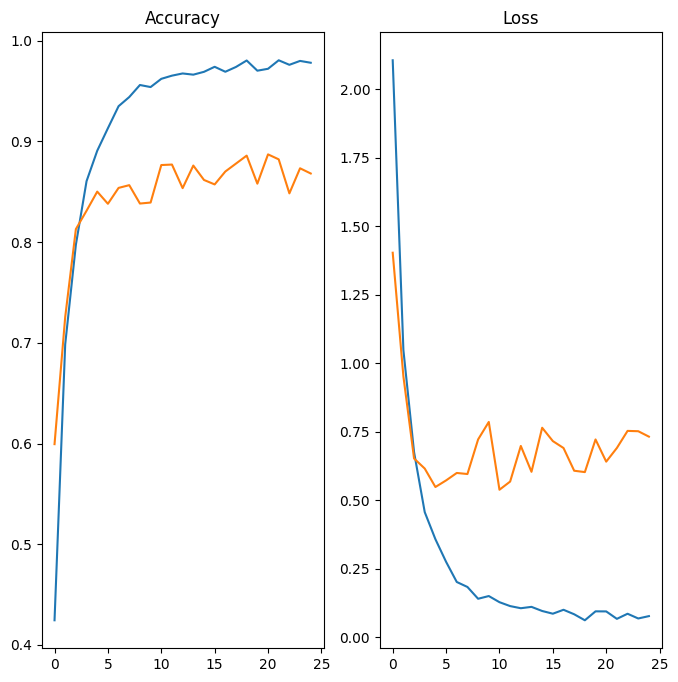

In [13]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [14]:
def show_image(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=(img_height,img_width))
    img_arr = tf.keras.utils.array_to_img(image)
    img_bat=tf.expand_dims(img_arr,0)
    predict = model.predict(img_bat)
    score = tf.nn.softmax(predict)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()
    print(f'The medicinal plant image is of {data_categories[np.argmax(score)]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


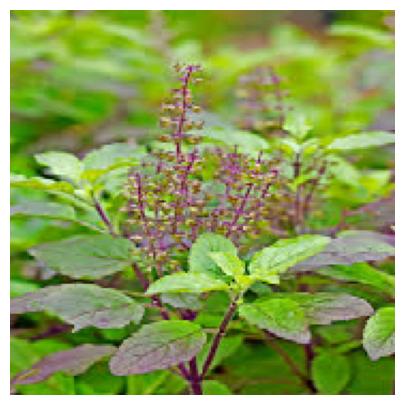

The medicinal plant image is of Mint


In [18]:
image_path = r"C:\Users\HP\Contacts\OneDrive\Desktop\images (1).jpeg".strip("\u202a\u202c")
show_image(image_path)